In [1]:
# - Build and compare multiple ML models
# - Create actionable business insights
# 
# **Models:** Logistic Regression, Random Forest, XGBoost
# 
# **Dataset:** Telco Customer Churn (Kaggle)

# ##  Section 1: Import Libraries and Setup

# ### Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Save models
import pickle

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" All libraries imported successfully!")
print(f" Notebook executed on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


 All libraries imported successfully!
 Notebook executed on: 2026-01-06 22:54:50


DATASET LOADED SUCCESSFULLY

 Dataset Shape: 7043 rows  21 columns
 Churn Rate: 26.54%

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null  

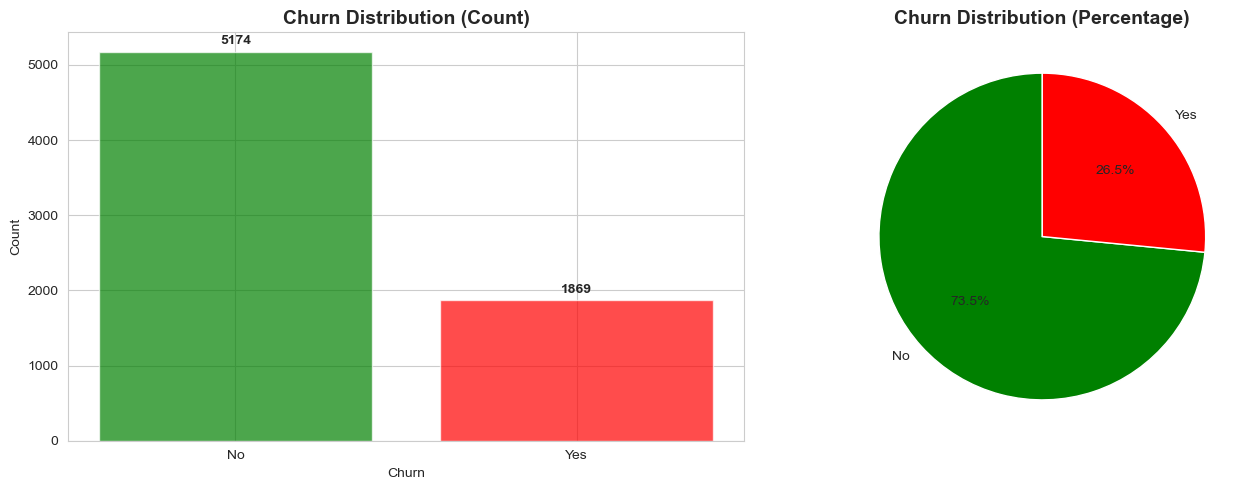


 Churn Statistics:
   Not Churned: 5174 (73.46%)
   Churned: 1869 (26.54%)


In [2]:
# ##  Section 2: Load and Explore Data

# ### 2.1 Load Dataset
# Load the Telco Customer Churn dataset
# Download from: https://www.kaggle.com/blastchar/telco-customer-churn

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)
print(f"\n Dataset Shape: {df.shape[0]} rows  {df.shape[1]} columns")
print(f" Churn Rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

# ### 2.2 Display First Few Rows
df.head(10)

# ### 2.3 Dataset Information
print("\n Dataset Info:")
df.info()

# ### 2.4 Statistical Summary
df.describe()

# ### 2.5 Check for Missing Values
print("\n Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(missing)
else:
    print(" No missing values found!")

# ### 2.6 Check Data Types
print("\n Data Types Distribution:")
print(df.dtypes.value_counts())

# ### 2.7 Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Percentage plot
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%', 
            colors=['green', 'red'], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Churn Statistics:")
print(f"   Not Churned: {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"   Churned: {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")


In [3]:
# ##  Section 3: Data Cleaning

# ### 3.1 Handle TotalCharges Column
print(" Cleaning TotalCharges column...")

# Convert to numeric (some values are spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for nulls created
print(f"   Missing values created: {df['TotalCharges'].isnull().sum()}")

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(" TotalCharges cleaned successfully!")

# ### 3.2 Remove Customer ID
print("\n Removing customerID column (not needed for prediction)...")
df_clean = df.drop('customerID', axis=1).copy()
print(f" Removed! New shape: {df_clean.shape}")

# ### 3.3 Verify No Missing Values
print("\n Final Missing Values Check:")
print(df_clean.isnull().sum().sum(), "missing values")

 Cleaning TotalCharges column...
   Missing values created: 11
 TotalCharges cleaned successfully!

 Removing customerID column (not needed for prediction)...
 Removed! New shape: (7043, 20)

 Final Missing Values Check:
0 missing values


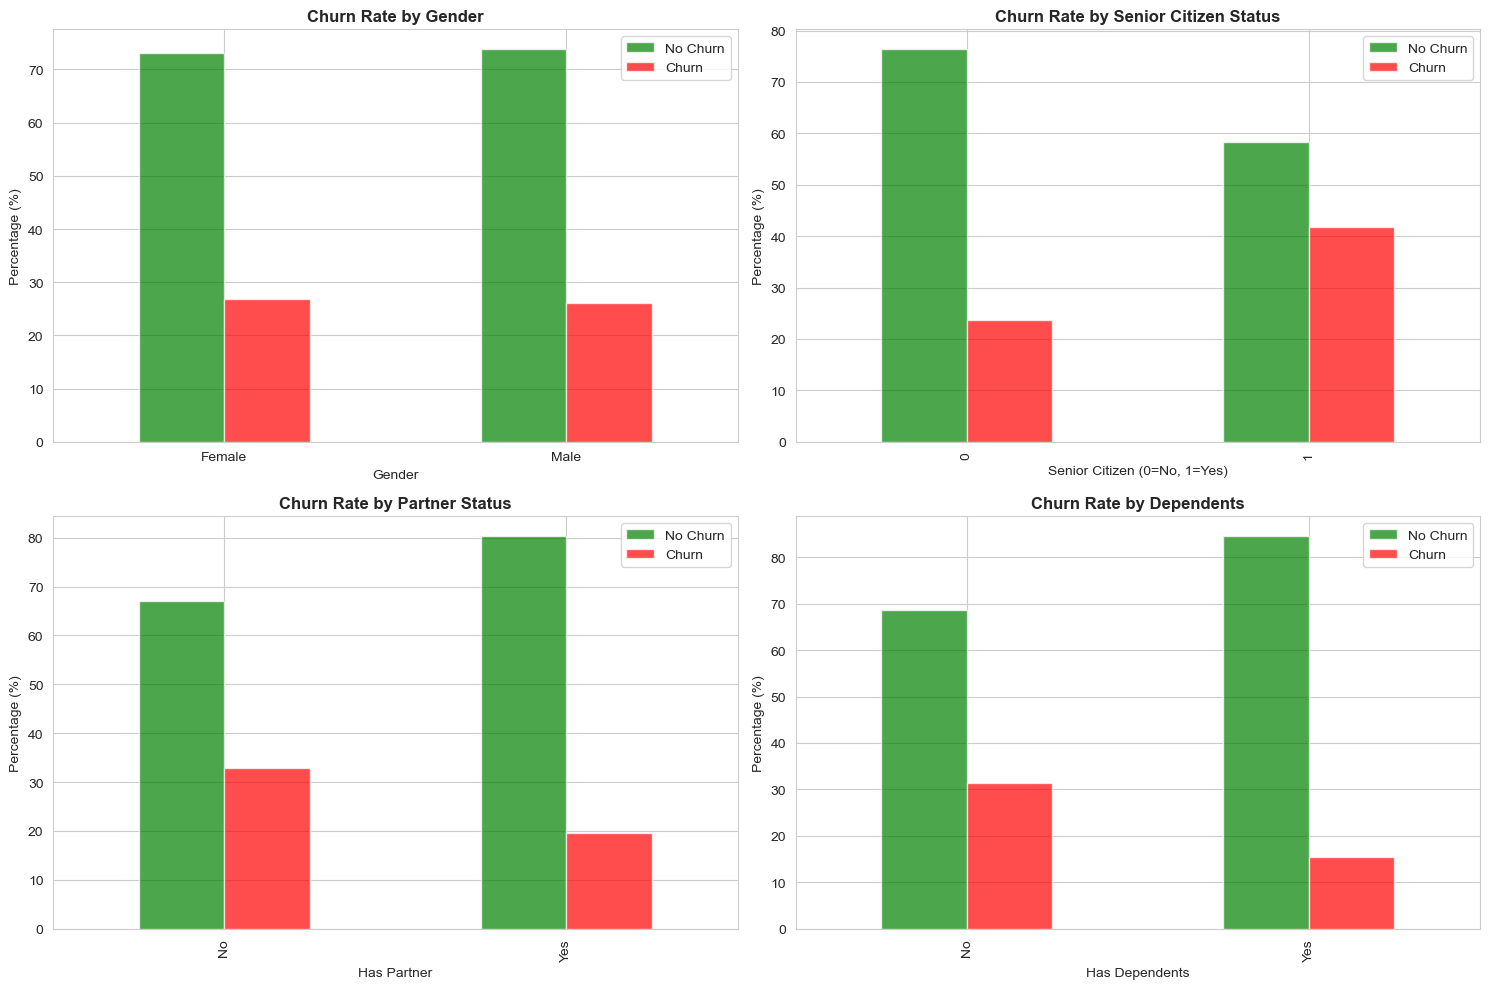

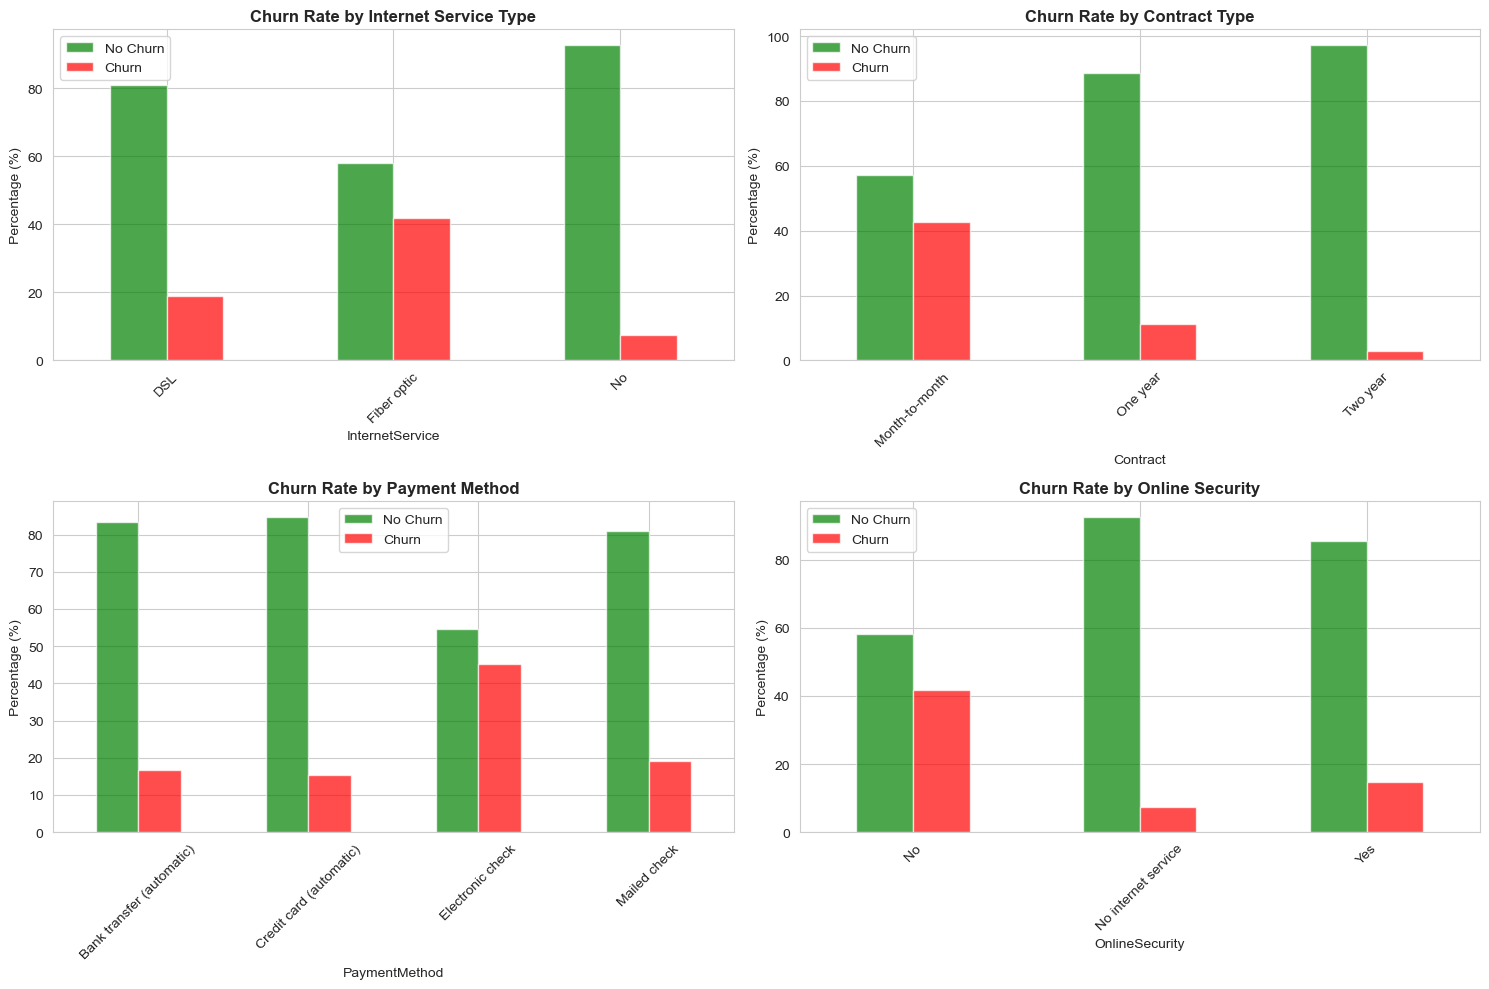

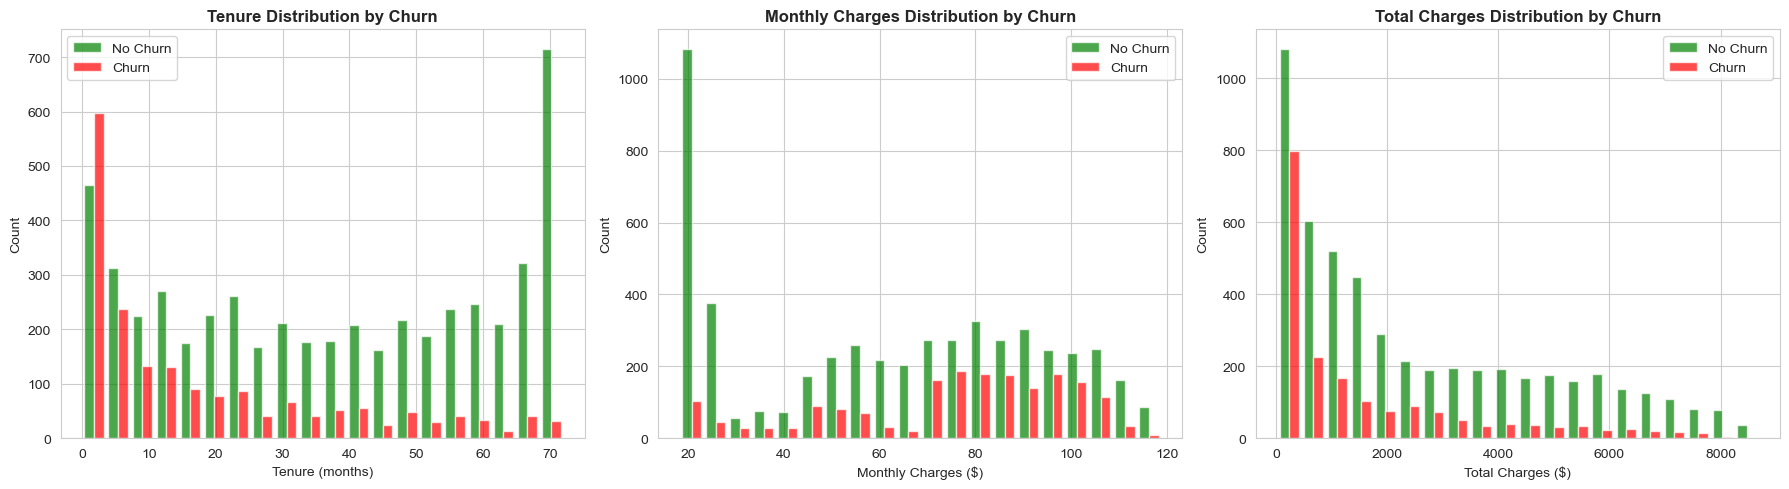

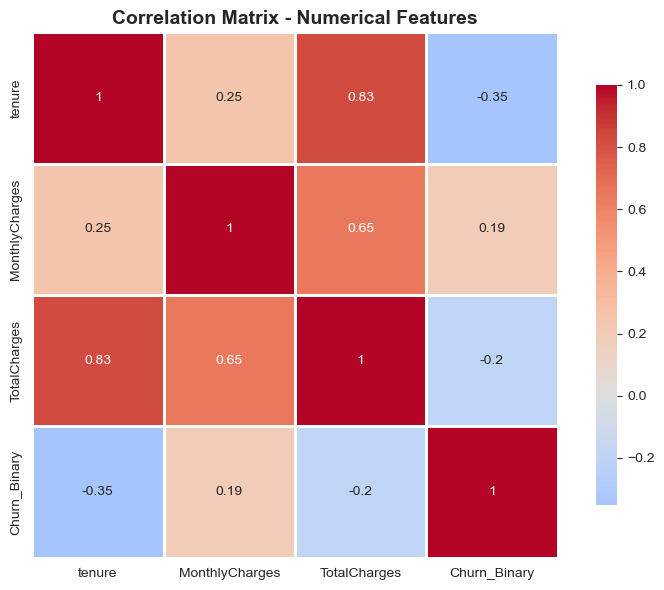

KEY INSIGHTS FROM EDA

 HIGH CHURN RISK FACTORS:
   ✓ Month-to-month contracts (highest churn)
   ✓ Fiber optic internet service users
   ✓ Electronic check payment method
   ✓ No online security services
   ✓ Short tenure (< 12 months)
   ✓ Higher monthly charges

 LOW CHURN RISK FACTORS:
   ✓ Long-term contracts (1-2 years)
   ✓ Has partner or dependents
   ✓ Multiple services (security, backup, etc.)
   ✓ Long tenure (> 24 months)
   ✓ Automatic payment methods


In [4]:
# ##  Section 4: Exploratory Data Analysis (EDA)

# ### 4.1 Churn by Demographics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender
gender_churn = pd.crosstab(df_clean['gender'], df_clean['Churn'], normalize='index') * 100
gender_churn.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Churn Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].legend(['No Churn', 'Churn'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Senior Citizen
senior_churn = pd.crosstab(df_clean['SeniorCitizen'], df_clean['Churn'], normalize='index') * 100
senior_churn.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'], alpha=0.7)
axes[0, 1].set_title('Churn Rate by Senior Citizen Status', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_xlabel('Senior Citizen (0=No, 1=Yes)')
axes[0, 1].legend(['No Churn', 'Churn'])

# Partner
partner_churn = pd.crosstab(df_clean['Partner'], df_clean['Churn'], normalize='index') * 100
partner_churn.plot(kind='bar', ax=axes[1, 0], color=['green', 'red'], alpha=0.7)
axes[1, 0].set_title('Churn Rate by Partner Status', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_xlabel('Has Partner')
axes[1, 0].legend(['No Churn', 'Churn'])

# Dependents
dep_churn = pd.crosstab(df_clean['Dependents'], df_clean['Churn'], normalize='index') * 100
dep_churn.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('Churn Rate by Dependents', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_xlabel('Has Dependents')
axes[1, 1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

# ### 4.2 Churn by Service Usage

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Internet Service
internet_churn = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Churn Rate by Internet Service Type', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['No Churn', 'Churn'])
axes[0, 0].tick_params(axis='x', rotation=45)

# Contract Type
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'], alpha=0.7)
axes[0, 1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(['No Churn', 'Churn'])
axes[0, 1].tick_params(axis='x', rotation=45)

# Payment Method
payment_churn = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', ax=axes[1, 0], color=['green', 'red'], alpha=0.7)
axes[1, 0].set_title('Churn Rate by Payment Method', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(['No Churn', 'Churn'])
axes[1, 0].tick_params(axis='x', rotation=45)

# Online Security
security_churn = pd.crosstab(df_clean['OnlineSecurity'], df_clean['Churn'], normalize='index') * 100
security_churn.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('Churn Rate by Online Security', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(['No Churn', 'Churn'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ### 4.3 Churn by Numerical Features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure
df_clean['Churn_Binary'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

axes[0].hist([df_clean[df_clean['Churn'] == 'No']['tenure'],
              df_clean[df_clean['Churn'] == 'Yes']['tenure']],
             bins=20, label=['No Churn', 'Churn'], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly Charges
axes[1].hist([df_clean[df_clean['Churn'] == 'No']['MonthlyCharges'],
              df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges']],
             bins=20, label=['No Churn', 'Churn'], color=['green', 'red'], alpha=0.7)
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Total Charges
axes[2].hist([df_clean[df_clean['Churn'] == 'No']['TotalCharges'],
              df_clean[df_clean['Churn'] == 'Yes']['TotalCharges']],
             bins=20, label=['No Churn', 'Churn'], color=['green', 'red'], alpha=0.7)
axes[2].set_title('Total Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# ### 4.4 Correlation Analysis

# Create correlation matrix for numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
correlation_matrix = df_clean[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ### 4.5 Key Insights from EDA

print("=" * 70)
print("KEY INSIGHTS FROM EDA")
print("=" * 70)

print("\n HIGH CHURN RISK FACTORS:")
print("   ✓ Month-to-month contracts (highest churn)")
print("   ✓ Fiber optic internet service users")
print("   ✓ Electronic check payment method")
print("   ✓ No online security services")
print("   ✓ Short tenure (< 12 months)")
print("   ✓ Higher monthly charges")

print("\n LOW CHURN RISK FACTORS:")
print("   ✓ Long-term contracts (1-2 years)")
print("   ✓ Has partner or dependents")
print("   ✓ Multiple services (security, backup, etc.)")
print("   ✓ Long tenure (> 24 months)")
print("   ✓ Automatic payment methods")

In [5]:
# ##  Section 5: Feature Engineering

print("\n FEATURE ENGINEERING")
print("=" * 70)

# ### 5.1 Create Tenure Groups
df_clean['TenureGroup'] = pd.cut(df_clean['tenure'], 
                                  bins=[0, 12, 24, 48, 72], 
                                  labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'])

print("✓ Created TenureGroup: Customer lifetime segments")

# ### 5.2 Average Monthly Charges
df_clean['AvgMonthlyCharges'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

print("✓ Created AvgMonthlyCharges: Average monthly spend")

# ### 5.3 Has Multiple Services
df_clean['HasMultipleServices'] = (
    (df_clean['OnlineSecurity'] == 'Yes') | 
    (df_clean['OnlineBackup'] == 'Yes') | 
    (df_clean['DeviceProtection'] == 'Yes') | 
    (df_clean['TechSupport'] == 'Yes')
).astype(int)

print("✓ Created HasMultipleServices: Multiple service adoption flag")

# ### 5.4 Has Phone and Internet Bundle
df_clean['HasPhoneAndInternet'] = (
    (df_clean['PhoneService'] == 'Yes') & 
    (df_clean['InternetService'] != 'No')
).astype(int)

print("✓ Created HasPhoneAndInternet: Bundle indicator")

# ### 5.5 Convert Paperless Billing to Binary
df_clean['PaperlessBilling'] = (df_clean['PaperlessBilling'] == 'Yes').astype(int)

print("✓ Converted PaperlessBilling to binary")

# ### 5.6 Display New Features
print(f"\n New Features Summary:")
print(f"   Total features: {df_clean.shape[1]}")
print(f"   Engineered features: 5")

# Show sample
print("\n Sample of Engineered Features:")
df_clean[['tenure', 'TenureGroup', 'AvgMonthlyCharges', 
          'HasMultipleServices', 'HasPhoneAndInternet']].head()


 FEATURE ENGINEERING
✓ Created TenureGroup: Customer lifetime segments
✓ Created AvgMonthlyCharges: Average monthly spend
✓ Created HasMultipleServices: Multiple service adoption flag
✓ Created HasPhoneAndInternet: Bundle indicator
✓ Converted PaperlessBilling to binary

 New Features Summary:
   Total features: 25
   Engineered features: 5

 Sample of Engineered Features:


,tenure,TenureGroup,AvgMonthlyCharges,HasMultipleServices,HasPhoneAndInternet
0,1,0-1yr,14.925000,1,0
1,34,2-4yr,53.985714,1,1
2,2,0-1yr,36.050000,1,1
3,45,2-4yr,40.016304,1,0
4,2,0-1yr,50.550000,0,1


In [6]:
# ##  Section 6: Data Preprocessing

print("\n DATA PREPROCESSING")
print("=" * 70)

# ### 6.1 Encode Target Variable
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print("✓ Target variable encoded (Yes=1, No=0)")

# ### 6.2 Separate Features and Target
X = df_clean.drop(['Churn', 'Churn_Binary'], axis=1)
y = df_clean['Churn']

print(f"✓ Features (X): {X.shape}")
print(f"✓ Target (y): {y.shape}")

# ### 6.3 Identify Column Types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n Column Types:")
print(f"   Categorical: {len(categorical_cols)} columns")
print(f"   Numerical: {len(numerical_cols)} columns")

# ### 6.4 Encode Categorical Variables
print("\n Encoding categorical variables...")

label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"✓ Encoded {len(categorical_cols)} categorical columns")

# ### 6.5 Scale Numerical Features
print("\n Scaling numerical features...")

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("✓ Scaled numerical features using StandardScaler")

# ### 6.6 Train-Test Split
print("\n Splitting data into train and test sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✓ Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"✓ Train churn rate: {y_train.mean()*100:.2f}%")
print(f"✓ Test churn rate: {y_test.mean()*100:.2f}%")

# ### 6.7 Save Preprocessing Objects
print("\n Saving preprocessing objects...")

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X_encoded.columns.tolist(), f)

print("✓ Saved: label_encoders.pkl, scaler.pkl, feature_columns.pkl")



 DATA PREPROCESSING
✓ Target variable encoded (Yes=1, No=0)
✓ Features (X): (7043, 23)
✓ Target (y): (7043,)

 Column Types:
   Categorical: 15 columns
   Numerical: 8 columns

 Encoding categorical variables...
✓ Encoded 15 categorical columns

 Scaling numerical features...
✓ Scaled numerical features using StandardScaler

 Splitting data into train and test sets...
✓ Training set: 5634 samples (80.0%)
✓ Test set: 1409 samples (20.0%)
✓ Train churn rate: 26.54%
✓ Test churn rate: 26.54%

 Saving preprocessing objects...
✓ Saved: label_encoders.pkl, scaler.pkl, feature_columns.pkl


In [7]:
# ##  Section 7: Model Training

print("\n MODEL TRAINING")
print("=" * 70)

models = {}
results = {}

# ### 7.1 Model 1: Logistic Regression

print("\n→ Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    class_weight='balanced',
    solver='lbfgs'
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

models['Logistic Regression'] = lr_model
results['Logistic Regression'] = {
    'predictions': lr_pred,
    'probabilities': lr_pred_proba,
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred),
    'recall': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'auc': roc_auc_score(y_test, lr_pred_proba)
}

print(f"   Trained successfully!")
print(f"     Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"     Precision: {results['Logistic Regression']['precision']:.4f}")
print(f"     Recall: {results['Logistic Regression']['recall']:.4f}")
print(f"     F1-Score: {results['Logistic Regression']['f1']:.4f}")
print(f"     AUC: {results['Logistic Regression']['auc']:.4f}")

# ### 7.2 Model 2: Random Forest

print("\n→ Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

models['Random Forest'] = rf_model
results['Random Forest'] = {
    'predictions': rf_pred,
    'probabilities': rf_pred_proba,
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'auc': roc_auc_score(y_test, rf_pred_proba)
}

print(f"   Trained successfully!")
print(f"     Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"     Precision: {results['Random Forest']['precision']:.4f}")
print(f"     Recall: {results['Random Forest']['recall']:.4f}")
print(f"     F1-Score: {results['Random Forest']['f1']:.4f}")
print(f"     AUC: {results['Random Forest']['auc']:.4f}")

# ### 7.3 Model 3: XGBoost

print("\n→ Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

models['XGBoost'] = xgb_model
results['XGBoost'] = {
    'predictions': xgb_pred,
    'probabilities': xgb_pred_proba,
    'accuracy': accuracy_score(y_test, xgb_pred),
    'precision': precision_score(y_test, xgb_pred),
    'recall': recall_score(y_test, xgb_pred),
    'f1': f1_score(y_test, xgb_pred),
    'auc': roc_auc_score(y_test, xgb_pred_proba)
}

print(f"   Trained successfully!")
print(f"     Accuracy: {results['XGBoost']['accuracy']:.4f}")
print(f"     Precision: {results['XGBoost']['precision']:.4f}")
print(f"     Recall: {results['XGBoost']['recall']:.4f}")
print(f"     F1-Score: {results['XGBoost']['f1']:.4f}")
print(f"     AUC: {results['XGBoost']['auc']:.4f}")

# ### 7.4 Select Best Model

best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = models[best_model_name]
best_results = results[best_model_name]

print("\n" + "=" * 70)
print(f" BEST MODEL: {best_model_name}")
print("=" * 70)
print(f"   AUC Score: {best_results['auc']:.4f}")
print(f"   Accuracy: {best_results['accuracy']:.4f}")
print(f"   Precision: {best_results['precision']:.4f}")
print(f"   Recall: {best_results['recall']:.4f}")
print(f"   F1-Score: {best_results['f1']:.4f}")

# ### 7.5 Save Best Model

print("\n Saving best model...")

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print(f"✓ Saved: best_model.pkl ({best_model_name})")


 MODEL TRAINING

→ Training Logistic Regression...
   Trained successfully!
     Accuracy: 0.7431
     Precision: 0.5105
     Recall: 0.7834
     F1-Score: 0.6181
     AUC: 0.8454

→ Training Random Forest...
   Trained successfully!
     Accuracy: 0.7679
     Precision: 0.5464
     Recall: 0.7406
     F1-Score: 0.6288
     AUC: 0.8387

→ Training XGBoost...
   Trained successfully!
     Accuracy: 0.7480
     Precision: 0.5185
     Recall: 0.7112
     F1-Score: 0.5998
     AUC: 0.8364

 BEST MODEL: Logistic Regression
   AUC Score: 0.8454
   Accuracy: 0.7431
   Precision: 0.5105
   Recall: 0.7834
   F1-Score: 0.6181

 Saving best model...
✓ Saved: best_model.pkl (Logistic Regression)



 MODEL EVALUATION

 Model Comparison:
              Model  Accuracy  Precision  Recall  F1-Score    AUC
Logistic Regression    0.7431     0.5105  0.7834    0.6181 0.8454
      Random Forest    0.7679     0.5464  0.7406    0.6288 0.8387
            XGBoost    0.7480     0.5185  0.7112    0.5998 0.8364

 Classification Report - Logistic Regression:
              precision    recall  f1-score   support

 Not Churned     0.9030    0.7285    0.8064      1035
     Churned     0.5105    0.7834    0.6181       374

    accuracy                         0.7431      1409
   macro avg     0.7067    0.7560    0.7123      1409
weighted avg     0.7988    0.7431    0.7564      1409


 Confusion Matrix - Logistic Regression:
                 Predicted No  |  Predicted Yes
                 -------------|---------------
Actual No           754       |     281  (False Positives)
Actual Yes           81       |     293  (True Positives)
              (False Negatives)|  

 Additional Metrics:
   True Nega

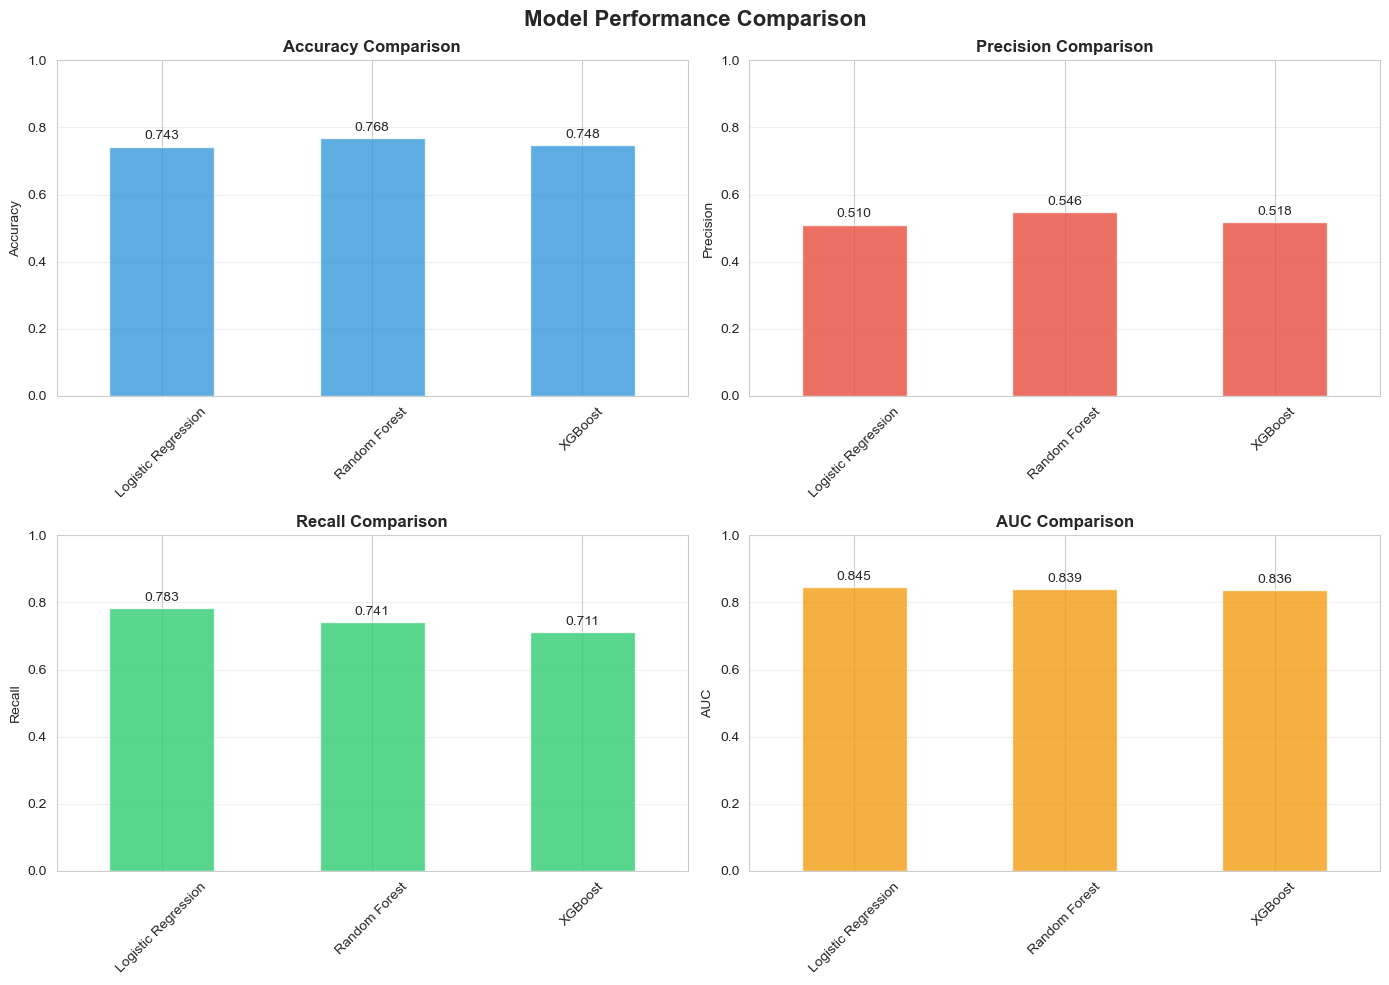

In [8]:
# ##  Section 8: Model Evaluation

print("\n MODEL EVALUATION")
print("=" * 70)

# ### 8.1 Model Comparison Table

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'AUC': [results[m]['auc'] for m in results]
}).round(4)

print("\n Model Comparison:")
print(comparison_df.to_string(index=False))

# Style the dataframe for better visualization
comparison_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'AUC'])

# ### 8.2 Detailed Classification Report

print(f"\n Classification Report - {best_model_name}:")
print("=" * 70)
print(classification_report(y_test, best_results['predictions'], 
                          target_names=['Not Churned', 'Churned'],
                          digits=4))

# ### 8.3 Confusion Matrix

cm = confusion_matrix(y_test, best_results['predictions'])

print(f"\n Confusion Matrix - {best_model_name}:")
print("=" * 70)
print(f"                 Predicted No  |  Predicted Yes")
print(f"                 -------------|---------------")
print(f"Actual No        {cm[0,0]:>6}       |  {cm[0,1]:>6}  (False Positives)")
print(f"Actual Yes       {cm[1,0]:>6}       |  {cm[1,1]:>6}  (True Positives)")
print(f"              (False Negatives)|  ")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\n Additional Metrics:")
print(f"   True Negatives: {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives: {tp}")
print(f"   Specificity: {specificity:.4f}")
print(f"   Sensitivity (Recall): {sensitivity:.4f}")

# ##  Section 9: Visualizations

print("\n CREATING VISUALIZATIONS")
print("=" * 70)

# ### 9.1 Model Comparison Chart

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, 
                      legend=False, color=colors[idx], alpha=0.8)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison.png")
plt.show()


✓ Saved: confusion_matrix.png


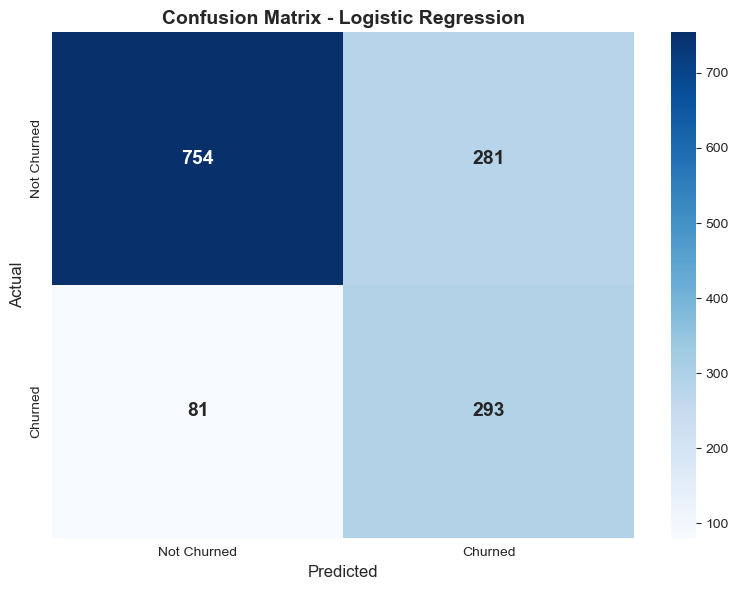

✓ Saved: roc_curves.png


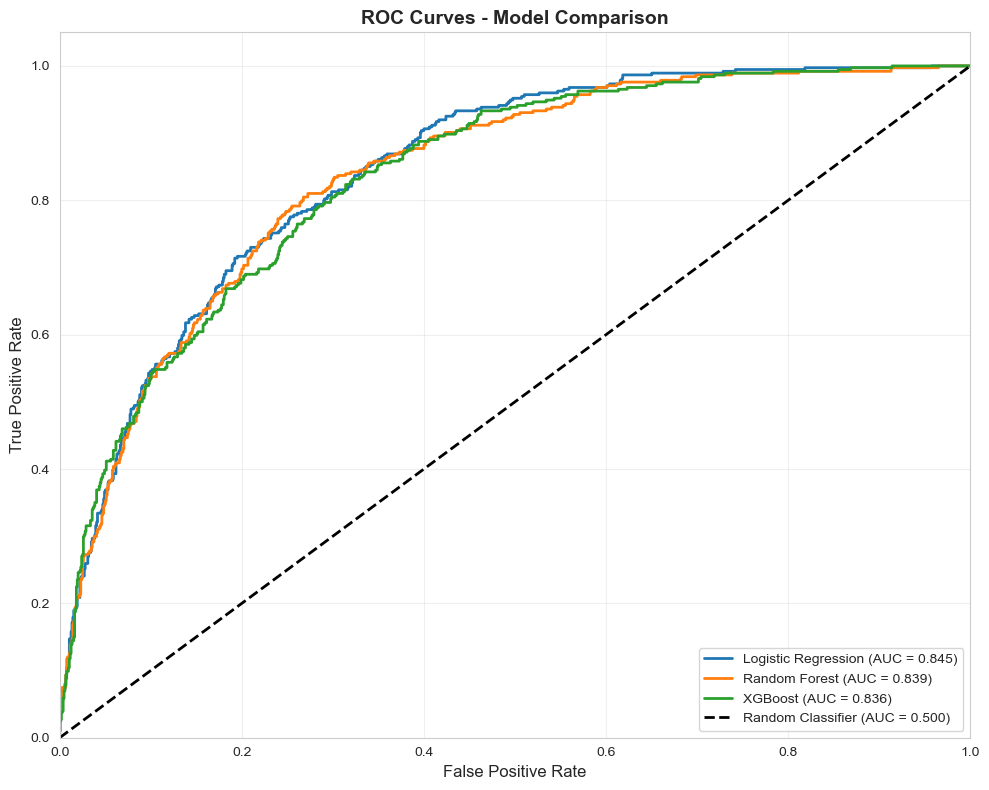

In [9]:
# ### 9.2 Confusion Matrix Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: confusion_matrix.png")
plt.show()

# ### 9.3 ROC Curves - All Models

plt.figure(figsize=(10, 8))

for model_name in results:
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['probabilities'])
    auc_score = results[model_name]['auc']
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ Saved: roc_curves.png")
plt.show()


✓ Saved: precision_recall.png


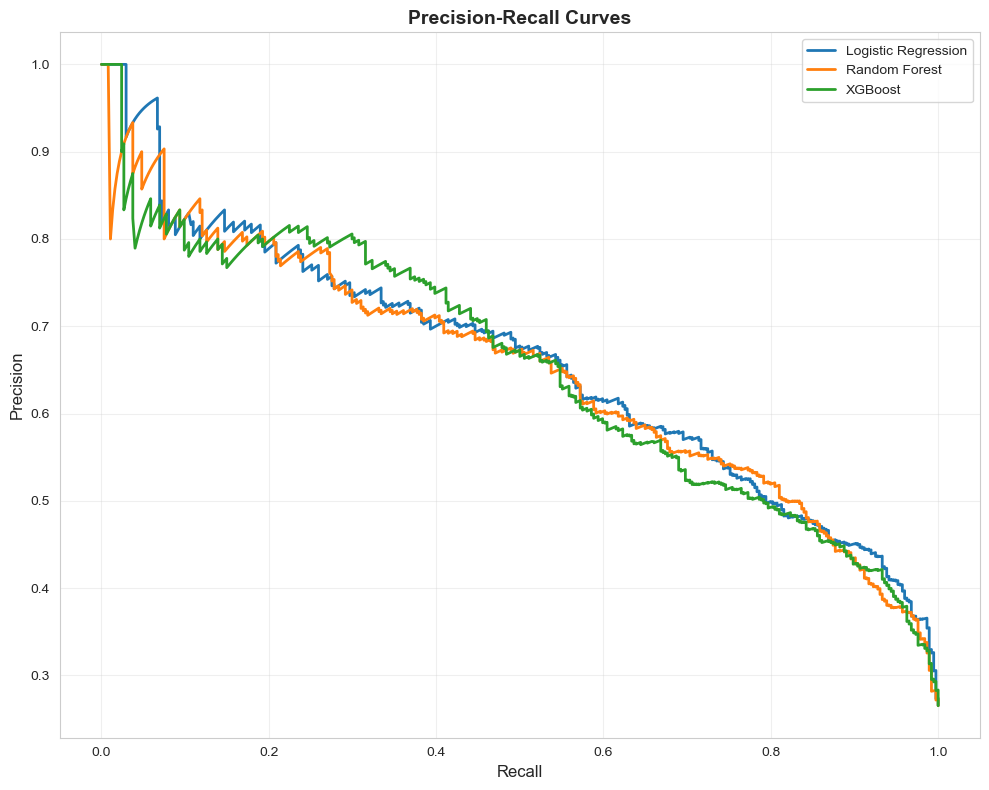

In [10]:
# ### 9.4 Precision-Recall Curves

plt.figure(figsize=(10, 8))

for model_name in results:
    precision, recall, _ = precision_recall_curve(y_test, results[model_name]['probabilities'])
    plt.plot(recall, precision, lw=2, label=f'{model_name}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=300, bbox_inches='tight')
print("✓ Saved: precision_recall.png")
plt.show()


In [11]:
# ### 9.5 Feature Importance (Tree-based models only)

if best_model_name in ['Random Forest', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance, x='Importance', y='Feature', 
                palette='viridis', orient='h')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: feature_importance.png")
    plt.show()

    # Display top 10 features
    print("\n🔝 Top 10 Most Important Features:")
    print("=" * 70)
    for idx, row in feature_importance.head(10).iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.4f}")
else:
    print(f"\n Feature importance not available for {best_model_name}")



 Feature importance not available for Logistic Regression


✓ Saved: probability_distribution.png


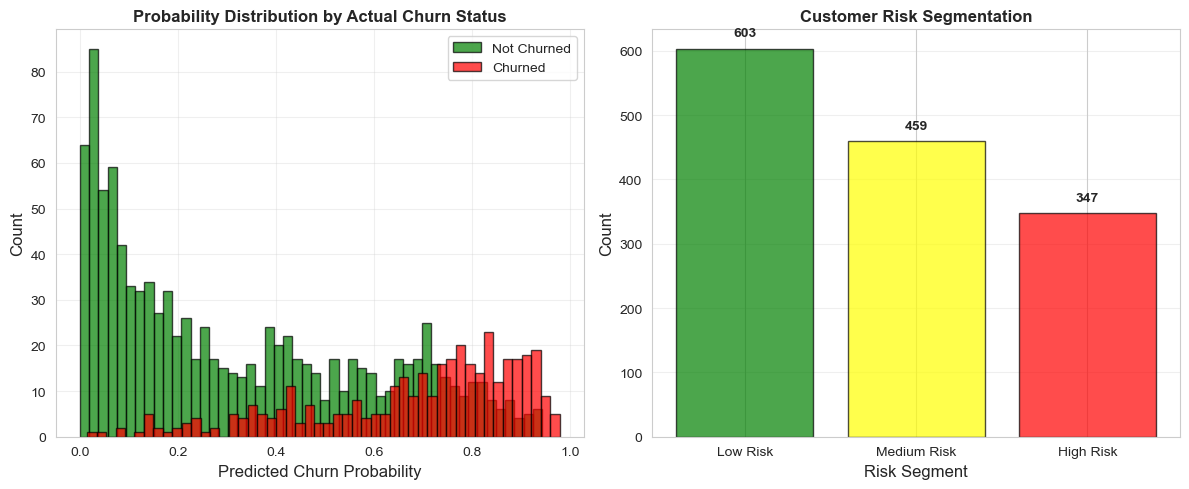

In [12]:
# ### 9.6 Prediction Probability Distribution

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(best_results['probabilities'][y_test == 0], bins=50, alpha=0.7, 
         label='Not Churned', color='green', edgecolor='black')
plt.hist(best_results['probabilities'][y_test == 1], bins=50, alpha=0.7, 
         label='Churned', color='red', edgecolor='black')
plt.xlabel('Predicted Churn Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability Distribution by Actual Churn Status', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
risk_segments = pd.cut(best_results['probabilities'], 
                       bins=[0, 0.3, 0.7, 1.0], 
                       labels=['Low Risk', 'Medium Risk', 'High Risk'])
risk_counts = risk_segments.value_counts().sort_index()
colors_risk = ['green', 'yellow', 'red']
plt.bar(risk_counts.index, risk_counts.values, color=colors_risk, alpha=0.7, edgecolor='black')
plt.xlabel('Risk Segment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Customer Risk Segmentation', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: probability_distribution.png")
plt.show()

In [13]:
# ##  Section 10: Save Predictions

print("\n SAVING PREDICTIONS")
print("=" * 70)

# ### 10.1 Create Predictions DataFrame

predictions_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Predicted_Churn': best_results['predictions'],
    'Churn_Probability': best_results['probabilities'],
    'Risk_Segment': pd.cut(best_results['probabilities'], 
                           bins=[0, 0.3, 0.7, 1.0], 
                           labels=['Low Risk', 'Medium Risk', 'High Risk'])
})

# Add back original features for analysis
predictions_df = pd.concat([
    predictions_df.reset_index(drop=True),
    X_test.reset_index(drop=True)
], axis=1)

print(f"✓ Created predictions dataframe: {predictions_df.shape}")



 SAVING PREDICTIONS
✓ Created predictions dataframe: (1409, 27)


In [14]:
# ### 10.2 Preview Predictions

print("\n Sample Predictions:")
predictions_df.head(10)


 Sample Predictions:


,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Segment,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,AvgMonthlyCharges,HasMultipleServices,HasPhoneAndInternet
0,0,0,0.131221,Low Risk,1,-0.439916,1,1,1.613701,1,2,1,2,2,2,2,2,2,2,0.829798,1,1.638143,2.731119,3,0.898615,0.810664,0.675774
1,0,1,0.818772,High Risk,0,2.273159,0,0,-0.992402,1,2,1,0,0,0,2,2,2,0,0.829798,1,1.176164,-0.606314,0,0.651911,0.810664,0.675774
2,0,0,0.191745,Low Risk,0,-0.439916,1,1,0.351370,1,2,0,2,2,2,0,2,0,1,0.829798,1,0.451620,0.410260,2,0.250490,0.810664,0.675774
3,0,1,0.510363,Medium Risk,1,-0.439916,1,0,-0.585198,1,0,1,0,0,2,2,0,0,0,-1.205113,2,0.446635,-0.358997,1,0.264347,0.810664,0.675774
4,0,0,0.081515,Low Risk,0,-0.439916,1,0,1.613701,1,2,0,2,2,2,0,2,2,2,0.829798,1,0.594535,1.605853,3,0.326370,0.810664,0.675774
5,0,1,0.830747,High Risk,0,-0.439916,0,0,-0.463037,1,2,1,0,2,0,0,2,2,0,0.829798,1,1.166193,-0.127750,1,0.481797,0.810664,0.675774
6,0,1,0.712246,High Risk,0,-0.439916,0,0,-0.463037,1,0,1,0,2,0,2,2,2,0,0.829798,0,1.142928,-0.143709,1,0.454867,0.810664,0.675774
7,0,0,0.311873,Medium Risk,1,-0.439916,0,1,-0.544478,1,2,2,1,1,1,1,1,1,0,0.829798,1,-1.351430,-0.813522,1,-0.642681,-1.233556,-1.479785
8,0,0,0.011053,Low Risk,0,-0.439916,1,1,1.165777,1,0,2,1,1,1,1,1,1,2,-1.205113,1,-1.496006,-0.428375,3,-0.655877,-1.233556,-1.479785
9,1,1,0.557973,Medium Risk,1,2.273159,0,0,-0.625919,1,0,0,0,0,0,0,0,0,0,0.829798,2,-0.655137,-0.667216,1,-0.300945,-1.233556,0.675774


In [15]:
# ### 10.3 Export to CSV

predictions_df.to_csv('churn_predictions.csv', index=False)
print("\n✓ Saved: churn_predictions.csv (for Power BI)")



✓ Saved: churn_predictions.csv (for Power BI)


In [16]:
# ### 10.3 Export to CSV

predictions_df.to_csv('churn_predictions.csv', index=False)
print("\n✓ Saved: churn_predictions.csv (for Power BI)")

# ### 10.4 Save Model Metadata

metadata = {
    'best_model': best_model_name,
    'metrics': {k: v for k, v in results[best_model_name].items() 
                if k not in ['predictions', 'probabilities']},
    'all_models': {m: {k: v for k, v in results[m].items() 
                       if k not in ['predictions', 'probabilities']} 
                   for m in results},
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_size': len(df),
    'train_size': len(X_train),
    'test_size': len(X_test)
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✓ Saved: model_metadata.pkl")


✓ Saved: churn_predictions.csv (for Power BI)
✓ Saved: model_metadata.pkl


In [17]:
# ##  Section 11: Business Insights

print("\n BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

# ### 11.1 Risk Segmentation Analysis

risk_distribution = predictions_df.groupby('Risk_Segment').agg({
    'Actual_Churn': ['count', 'sum', 'mean']
}).round(4)

risk_distribution.columns = ['Total_Customers', 'Actual_Churners', 'Churn_Rate']

print("\n Customer Risk Segmentation:")
print(risk_distribution)


 BUSINESS INSIGHTS & RECOMMENDATIONS

 Customer Risk Segmentation:
              Total_Customers  Actual_Churners  Churn_Rate
Risk_Segment                                              
Low Risk                  603               25      0.0415
Medium Risk               459              134      0.2919
High Risk                 347              215      0.6196


In [18]:
# ### 11.2 Calculate Business Impact

total_customers = len(predictions_df)
actual_churners = predictions_df['Actual_Churn'].sum()
predicted_churners = predictions_df['Predicted_Churn'].sum()
correctly_identified = ((predictions_df['Actual_Churn'] == 1) & 
                        (predictions_df['Predicted_Churn'] == 1)).sum()

retention_cost_per_customer = 100  # Assumed $100 per retention campaign
avg_customer_value = 1000  # Assumed $1000 annual value

total_retention_cost = predicted_churners * retention_cost_per_customer
potential_revenue_saved = correctly_identified * avg_customer_value
false_positive_cost = fp * retention_cost_per_customer
net_benefit = potential_revenue_saved - total_retention_cost

print("\n Business Impact Analysis:")
print("=" * 70)
print(f"Total Customers: {total_customers:,}")
print(f"Actual Churners: {actual_churners} ({actual_churners/total_customers*100:.2f}%)")
print(f"Predicted Churners: {predicted_churners}")
print(f"Correctly Identified Churners: {correctly_identified} ({correctly_identified/actual_churners*100:.1f}% of all churners)")
print(f"\nRetention Campaign Cost:")
print(f"   Cost per customer: ${retention_cost_per_customer}")
print(f"   Total campaign cost: ${total_retention_cost:,}")
print(f"   False positive cost: ${false_positive_cost:,}")
print(f"\nPotential Revenue Saved:")
print(f"   Avg customer value: ${avg_customer_value}")
print(f"   Customers saved: {correctly_identified}")
print(f"   Total revenue saved: ${potential_revenue_saved:,}")
print(f"\nNet Benefit: ${net_benefit:,}")
print(f"ROI: {(net_benefit/total_retention_cost)*100:.1f}%")



 Business Impact Analysis:
Total Customers: 1,409
Actual Churners: 374 (26.54%)
Predicted Churners: 574
Correctly Identified Churners: 293 (78.3% of all churners)

Retention Campaign Cost:
   Cost per customer: $100
   Total campaign cost: $57,400
   False positive cost: $28,100

Potential Revenue Saved:
   Avg customer value: $1000
   Customers saved: 293
   Total revenue saved: $293,000

Net Benefit: $235,600
ROI: 410.5%


In [19]:
# ### 11.3 Key Recommendations

print("\n KEY RECOMMENDATIONS:")
print("=" * 70)

high_risk_count = (predictions_df['Risk_Segment'] == 'High Risk').sum()
medium_risk_count = (predictions_df['Risk_Segment'] == 'Medium Risk').sum()

print(f"\n1. IMMEDIATE ACTION (High Risk: {high_risk_count} customers)")
print("   → Offer personalized retention incentives")
print("   → Schedule proactive customer success calls")
print("   → Provide service upgrade discounts (15-20% off)")
print("   → Fast-track any pending service issues")

print(f"\n2. PREVENTIVE MEASURES (Medium Risk: {medium_risk_count} customers)")
print("   → Send satisfaction surveys")
print("   → Highlight value-added services")
print("   → Enroll in loyalty programs")
print("   → Monitor usage patterns closely")

print("\n3. PRODUCT/SERVICE IMPROVEMENTS:")
print("   → Incentivize long-term contracts (reduce month-to-month)")
print("   → Bundle services with discounts")
print("   → Improve fiber optic service quality")
print("   → Promote automatic payment methods")
print("   → Offer online security/backup for free initially")

print("\n4. TARGETING STRATEGY:")
print("   → Focus on customers with < 12 months tenure")
print("   → Target electronic check users for payment method switch")
print("   → Offer contract upgrades to month-to-month customers")



 KEY RECOMMENDATIONS:

1. IMMEDIATE ACTION (High Risk: 347 customers)
   → Offer personalized retention incentives
   → Schedule proactive customer success calls
   → Provide service upgrade discounts (15-20% off)
   → Fast-track any pending service issues

2. PREVENTIVE MEASURES (Medium Risk: 459 customers)
   → Send satisfaction surveys
   → Highlight value-added services
   → Enroll in loyalty programs
   → Monitor usage patterns closely

3. PRODUCT/SERVICE IMPROVEMENTS:
   → Incentivize long-term contracts (reduce month-to-month)
   → Bundle services with discounts
   → Improve fiber optic service quality
   → Promote automatic payment methods
   → Offer online security/backup for free initially

4. TARGETING STRATEGY:
   → Focus on customers with < 12 months tenure
   → Target electronic check users for payment method switch
   → Offer contract upgrades to month-to-month customers


In [20]:
# ##  Section 12: Summary & Next Steps

print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"\n COMPLETED TASKS:")
print("   1. ✓ Data exploration and cleaning")
print("   2. ✓ Feature engineering (5 new features)")
print("   3. ✓ Trained 3 ML models (Logistic Regression, Random Forest, XGBoost)")
print("   4. ✓ Model evaluation and comparison")
print("   5. ✓ Created 6 visualization charts")
print("   6. ✓ Generated business insights and recommendations")
print("   7. ✓ Exported predictions for Power BI")

print(f"\n BEST MODEL PERFORMANCE:")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {best_results['accuracy']:.2%}")
print(f"   Precision: {best_results['precision']:.2%}")
print(f"   Recall: {best_results['recall']:.2%}")
print(f"   F1-Score: {best_results['f1']:.2%}")
print(f"   AUC: {best_results['auc']:.4f}")

print(f"\n OUTPUT FILES:")
print("   1. best_model.pkl - Trained model")
print("   2. label_encoders.pkl - Categorical encoders")
print("   3. scaler.pkl - Feature scaler")
print("   4. feature_columns.pkl - Feature names")
print("   5. model_metadata.pkl - Model metrics")
print("   6. churn_predictions.csv - Predictions for Power BI")
print("   7. model_comparison.png - Performance comparison")
print("   8. confusion_matrix.png - Confusion matrix")
print("   9. roc_curves.png - ROC curves")
print("  10. precision_recall.png - Precision-recall curves")
print("  11. feature_importance.png - Top features")
print("  12. probability_distribution.png - Risk segments")

print(f"\n NEXT STEPS:")
print("   1. Run Streamlit app: streamlit run streamlit_app.py")
print("   2. Import churn_predictions.csv to Power BI")
print("   3. Create interactive dashboard")
print("   4. Deploy retention campaigns for high-risk customers")
print("   5. Monitor model performance and retrain monthly")

print("\n" + "=" * 70)
print(" NOTEBOOK EXECUTION COMPLETE!")
print("=" * 70)


PROJECT SUMMARY

 COMPLETED TASKS:
   1. ✓ Data exploration and cleaning
   2. ✓ Feature engineering (5 new features)
   3. ✓ Trained 3 ML models (Logistic Regression, Random Forest, XGBoost)
   4. ✓ Model evaluation and comparison
   5. ✓ Created 6 visualization charts
   6. ✓ Generated business insights and recommendations
   7. ✓ Exported predictions for Power BI

 BEST MODEL PERFORMANCE:
   Model: Logistic Regression
   Accuracy: 74.31%
   Precision: 51.05%
   Recall: 78.34%
   F1-Score: 61.81%
   AUC: 0.8454

 OUTPUT FILES:
   1. best_model.pkl - Trained model
   2. label_encoders.pkl - Categorical encoders
   3. scaler.pkl - Feature scaler
   4. feature_columns.pkl - Feature names
   5. model_metadata.pkl - Model metrics
   6. churn_predictions.csv - Predictions for Power BI
   7. model_comparison.png - Performance comparison
   8. confusion_matrix.png - Confusion matrix
   9. roc_curves.png - ROC curves
  10. precision_recall.png - Precision-recall curves
  11. feature_importan